In [3]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os

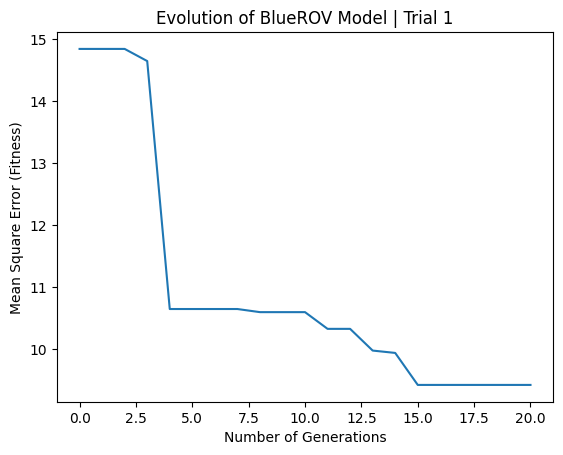

In [27]:
prelim_dir = "/home/gonzaeve/hpc-share/uvms/preliminary"
trials = ["trial_0", "trial_0a", "trial_0b"]

def process_trial(trial_dir):
    # Return list of csvs as pandas data frames
    # Get the list of csv files. One for each generation
    csv_list = [f for f in os.listdir(trial_dir) if f[-4:] == ".csv"]
    # Get all the numbers for each csv file. Sort them by order
    nums = [f.split("_")[-1] for f in csv_list]
    nums = [int(f.split(".")[0]) for f in nums]
    nums.sort()
    dfs = []
    for num in nums:
        csv_dir = os.path.join(trial_dir, "gen_"+str(num)+".csv")
        with open(csv_dir, newline='') as file:
            dfs.append(pd.read_csv(csv_dir))
    return dfs

def process_dfs(dfs):
    fitnesses = [min(df["fitness"]) for df in dfs]
    return fitnesses


all_dfs = [process_trial(os.path.join(prelim_dir, trial)) for trial in trials]
all_fit = [process_dfs(dfs) for dfs in all_dfs]

i = 1
plt.plot(list(range( len(all_fit[i]) )), all_fit[i])
plt.ylabel("Mean Square Error (Fitness)")
plt.xlabel("Number of Generations")
plt.title("Evolution of BlueROV Model | Trial "+str(i))
plt.show()